In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pennylane as qml
import itertools
import random
from random import sample
from sklearn.linear_model import Ridge
from scipy import sparse
import pandas as pd

#from QRC import *

In [ ]:

def get_pauli_matrix(observable_name):
    if observable_name == 'X':
        return np.array([[0, 1], [1, 0]], dtype=complex)
    elif observable_name == 'Z':
        return np.array([[1, 0], [0, -1]], dtype=complex)
    else:
        raise ValueError(f"Unsupported pauli: {observable_name}")
    
def create_observable_matrix(observable, num_qubits, target_wire):
    """
    Erzeugt die Matrix einer Observable (Pauli X oder Z) auf einem bestimmten Wire.
    - observable: Klasse oder Instanz (z.B. qml.PauliX oder qml.PauliX(...))
    - num_qubits: totale Anzahl Qubits (z.B. self.nqbits + 1)
    - target_wire: Index des Qubits, auf dem die Pauli-Matrix wirkt (0..num_qubits-1)
    """
    # robusten Namen extrahieren (Klasse oder Instanz)
    if hasattr(observable, "__name__"):
        name = observable.__name__
    else:
        # eventuelle Instanz, dann nimmt die Klassenbezeichnung
        name = observable.__class__.__name__

    if name == 'PauliX':
        pauli = get_pauli_matrix('X')
    elif name == 'PauliZ':
        pauli = get_pauli_matrix('Z')
    else:
        raise ValueError(f"Unsupported observable: {name}")

    # Start mit Skalar/1 (nicht 2x2), danach für jeden Qubit Kronprodukt anwenden.
    result = np.array([1.], dtype=complex).reshape(1, 1)
    for i in range(num_qubits):
        if i == target_wire:
            result = np.kron(result, pauli)
        else:
            result = np.kron(result, np.eye(2, dtype=complex))
    return result



def partial_trace(rho, keep, dims):
    n = len(dims)
    keep = np.asarray(keep)
    dims = np.asarray(dims)
    trace_out = np.delete(np.arange(n), keep)
    reshape = np.append(dims, dims)
    rho = rho.reshape(reshape)
    for k in trace_out[::-1]:
        rho = np.trace(rho, axis1=k, axis2=k+n)
    dim_tot = np.prod(dims[keep])
    return rho.reshape(dim_tot, dim_tot)

class QuantumRCFixed:
    def __init__(self, nqbits=6, num_gates=20, gates_set=['CNOT', 'T', 'H'], alpha=1e-1, t=10):
        self.nqbits = nqbits
        self.num_gates = num_gates
        self.gates_set = gates_set
        self.lm = None
        self.rho = None
        self.alpha = alpha
        self.t = t
        self.dev = qml.device("default.qubit", wires=self.nqbits + 1)
        if gates_set == 'Ising':
            self.U = self.get_unitary_ising()
        else:
            self.U = self.get_unitary()
        self.observables = self.get_observables()
        self.valid_cols = None
        self.max_len = None

    def get_unitary_ising(self):
        def ising_circuit(init_state):
            qml.StatePrep(init_state, wires=range(self.nqbits + 1))
            qubit_idx = list(range(self.nqbits + 1))
            qubit_pairs = list(itertools.combinations(qubit_idx, 2))
            Js = 1
            h_over_Js = 0.1
            h = Js * h_over_Js
            for pair in qubit_pairs:
                coef = np.random.uniform(-Js/2, Js/2)
                qml.IsingZZ(coef * self.t, wires=[pair[0], pair[1]])
            for qubit in qubit_idx:
                qml.RX(2 * h * self.t, wires=qubit)
            return qml.state()
        circuit = qml.QNode(ising_circuit, self.dev)
        U = np.zeros((2**(self.nqbits + 1), 2**(self.nqbits + 1)), dtype=complex)
        for i in range(2**(self.nqbits + 1)):
            init_state = np.zeros(2**(self.nqbits + 1))
            init_state[i] = 1
            U[:, i] = circuit(init_state)
            
        return U

    def get_unitary(self):
        def random_circuit(init_state):
            qml.StatePrep(init_state, wires=range(self.nqbits + 1))
            for _ in range(self.num_gates):
                gate = random.choice(self.gates_set)
                if gate == 'CNOT':
                    control = random.randint(0, self.nqbits)
                    target = random.choice([i for i in range(self.nqbits + 1) if i != control])
                    qml.CNOT(wires=[control, target])
                elif gate == 'H':
                    qubit = random.randint(0, self.nqbits)
                    qml.Hadamard(wires=qubit)
                elif gate == 'T':
                    qubit = random.randint(0, self.nqbits)
                    qml.PhaseShift(np.pi/4, wires=qubit)
                elif gate == 'X':
                    qubit = random.randint(0, self.nqbits)
                    qml.PauliX(wires=qubit)
                elif gate == 'S':
                    qubit = random.randint(0, self.nqbits)
                    qml.PhaseShift(np.pi/2, wires=qubit)
            return qml.state()
        circuit = qml.QNode(random_circuit, self.dev)
        U = np.zeros((2**(self.nqbits + 1), 2**(self.nqbits + 1)), dtype=complex)
        for i in range(2**(self.nqbits + 1)):
            init_state = np.zeros(2**(self.nqbits + 1))
            init_state[i] = 1
            U[:, i] = circuit(init_state)
        return U

    def get_observables(self):
        observables = []
        for i in range(self.nqbits + 1):
            observables.append(lambda idx=i: qml.PauliX(wires=idx))
            observables.append(lambda idx=i: qml.PauliZ(wires=idx))
        return observables

    def train(self, X_train_scaled, y_train_scaled, scaler):
        psi_datas = np.zeros((y_train_scaled.shape[0]+1, 2))
        psi_datas[0] = np.array([1, 0])
        for i in range(y_train_scaled.shape[0]):
            psi_datas[i+1] = np.sqrt(1-y_train_scaled[i])*np.array([1,0]) + np.sqrt(y_train_scaled[i])*np.array([0,1])
        self.psi_datas_train = psi_datas
        input_state = psi_datas[0]
        bell_state = np.ones(2**self.nqbits)/np.sqrt(2**self.nqbits)
        psi = np.kron(input_state, bell_state).flatten().reshape(-1,1)
        self.rho = psi @ psi.conj().T
        assert self.rho.shape == self.U.shape, f"Initial rho shape {self.rho.shape} does not match U shape {self.U.shape}"
        X_trainQ = []
        for i in range(1, y_train_scaled.shape[0]):
            rho_total = self.U @ self.rho @ self.U.conj().T
            assert rho_total.shape == self.U.shape, f"rho_total shape {rho_total.shape} does not match U shape {self.U.shape}"
            dims = [2] * (self.nqbits + 1)
            keep_qubits = list(range(1, self.nqbits + 1))
            rho_partial = partial_trace(rho_total, keep_qubits, dims)
            psi = psi_datas[i].flatten().reshape(-1,1)
            psi_new = psi @ psi.conj().T
            self.rho = np.kron(psi_new, rho_partial)
            assert self.rho.shape == self.U.shape, f"Updated rho shape {self.rho.shape} does not match U shape {self.U.shape}"
            results = []
            for idx, obs in enumerate(self.observables):
                observable_matrix = create_observable_matrix(obs(0).__class__, self.nqbits + 1, idx // 2)
                expect = np.real(np.trace(observable_matrix @ rho_total))
                results.append(expect)
                
            X_trainQ.append(results)
        
        self.max_len = max(len(row) for row in X_trainQ) if X_trainQ else 0
        X_trainQ_arr = np.full((len(X_trainQ), self.max_len), np.nan)
        for i, row in enumerate(X_trainQ):
            X_trainQ_arr[i, :len(row)] = row
        self.valid_cols = ~np.all(np.isnan(X_trainQ_arr), axis=0)
        X_trainQ_arr = X_trainQ_arr[:, self.valid_cols]
        X_train = np.hstack([X_trainQ_arr, X_train_scaled[1:]])
        
        self.lm = Ridge(alpha=self.alpha)
        self.lm.fit(X_train, y_train_scaled[1:].reshape(-1,1))
        y_train_pred = self.lm.predict(X_train)
        y_train_pred = scaler.inverse_transform(y_train_pred.reshape(-1, 1)).flatten()
        return y_train_pred

    def test(self, X_test_scaled, scaler):
        n_test = X_test_scaled.shape[0]
        psi_datas_test = np.zeros((n_test+1, 2))
        psi_datas_test[0] = self.psi_datas_train[-1]
        y_pred_seq = []
        for i in range(n_test):
            if i == 0:
                # Use last training output (already scaled) as initial drive
                y_drive = (np.array([self.psi_datas_train[-1][1]]).reshape(-1,1)).flatten()[0]
            else:
                y_drive = scaler.transform(np.array([y_pred_seq[-1]]).reshape(-1,1)).flatten()[0]
            
            psi_datas_test[i+1] = np.sqrt(1-y_drive)*np.array([1,0]) + np.sqrt(y_drive)*np.array([0,1])
            psi = psi_datas_test[i+1].flatten().reshape(-1,1)
            psi_new = psi @ psi.conj().T
            
            dims = [2] * (self.nqbits + 1)
            keep_qubits = list(range(1, self.nqbits + 1))
            rho_partial = partial_trace(self.rho, keep_qubits, dims)
            self.rho = np.kron(psi_new, rho_partial)
            rho_total = self.U @ self.rho @ self.U.conj().T
            
            results = []
            for idx, obs in enumerate(self.observables):
                observable_matrix = create_observable_matrix(obs(0).__class__, self.nqbits + 1, idx // 2)
                
                expect = np.real(np.trace(observable_matrix @ rho_total))
                results.append(expect)
            results = np.array(results)
            
            if len(results) < self.max_len:
                results = np.pad(results, (0, self.max_len - len(results)), constant_values=np.nan)
            results = results[self.valid_cols]
            X_testQ = results.reshape(1,-1)
            X_test = np.hstack([X_testQ, X_test_scaled[i].reshape(1,-1)])
            y_hat = self.lm.predict(X_test.reshape(1,-1))
            if y_hat[0] > 1:
                y_hat[0] = 1-0.001
            elif y_hat[0] < 0:
                y_hat[0] = 0.001
            y_hat = scaler.inverse_transform(y_hat.reshape(-1, 1)).flatten()[0]
            y_pred_seq.append(y_hat)
        return np.array(y_pred_seq)

In [22]:
# Generate mock time series data
def generate_mock_data(n_points=1000):
    np.random.seed(42)  # Set seed for reproducibility
    t = np.linspace(0, 100, n_points)
    # Create a complex time series with multiple components
    series = (
        np.sin(0.1 * t) +  # Long-term trend
        0.5 * np.sin(0.5 * t) +  # Medium-term cycle
        0.2 * np.sin(2.0 * t) +  # Short-term oscillation
        0.1 * np.random.randn(n_points)  # Random noise
    )
    return series

# use Stock data as dataset 
def import_stocks():
    data = pd.read_csv('stocks_daily.csv', on_bad_lines='warn')
    data.Datetime = pd.to_datetime(data.Datetime)
    y = data.Close[data.symbol=='AMZN']
    return np.array(y)

# Prepare data for training and testing
def prepare_data(data, lookback=20, train_split=0.7):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback)])
        y.append(data[i + lookback])
    
    X = np.array(X)
    y = np.array(y)
    
    # Split into train and test sets
    train_size = int(len(X) * train_split)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    # Scale the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Create a separate scaler for y values
    y_scaler = MinMaxScaler(feature_range=(0, 1))
    y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()
    
    return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, y_scaler

def plot_results(y_true, y_pred, title):
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label='True', alpha=0.7)
    plt.plot(y_pred, label='Predicted', alpha=0.7)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()



Importing stock data...
Preparing data...
Initializing Quantum Reservoir Computing...
Training QRC...
Testing QRC...
Plotting results...


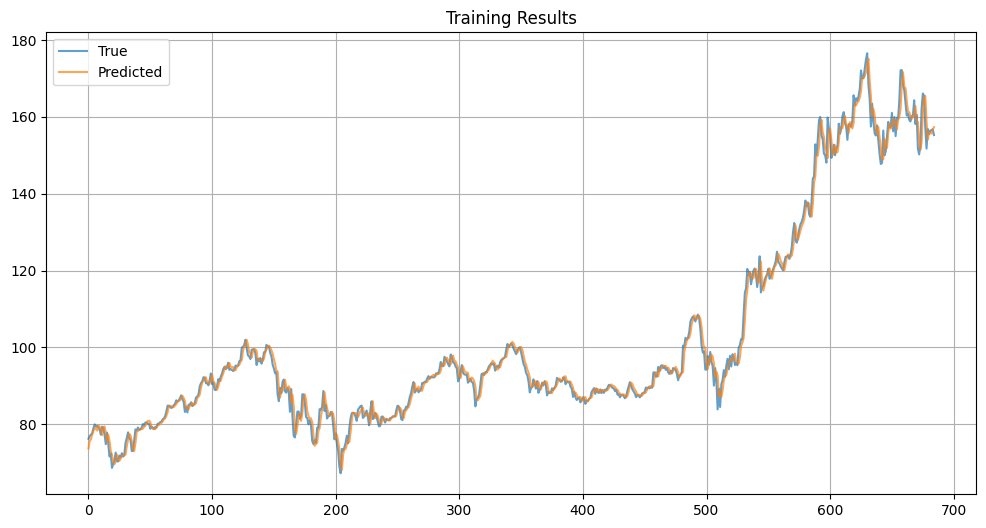

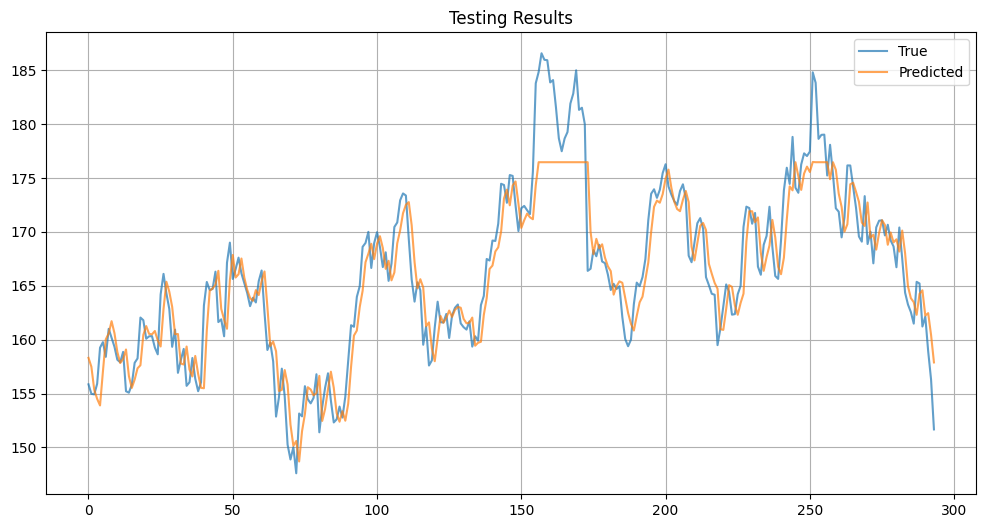


Results:
Number Qubits: 4
Number of Gates: 80
Gates Set: Ising
Alpha: 0.1
t: 15
Training MSE: 5.240810
Testing MSE: 9.340501


In [140]:
# Parameters
n_points = 1000
lookback = 20
train_split = 0.7

# Generate mock data
#print("Generating mock data...")
#data = generate_mock_data(n_points)

# Use stock data
print("Importing stock data...")
data = import_stocks()
data = data[:n_points]  # Limit to n_points for quicker testing

# Prepare data
print("Preparing data...")
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, scaler = prepare_data(
    data, lookback, train_split
)

nqbits=4  # Using minimal number of qubits for testing
num_gates=80 # Reduced number of gates
#gates_set=['CNOT', 'H', 'T']
gates_set='Ising'
alpha=0.1
t=15


# Initialize and train QRC
print("Initializing Quantum Reservoir Computing...")
qrc = QuantumRCFixed(
    nqbits=nqbits,  # Using minimal number of qubits for testing
    num_gates=num_gates,  # Reduced number of gates
    gates_set=gates_set,
    #gates_set='Ising',
    alpha=alpha,
    t=t)
    
# Train the model
print("Training QRC...")
y_train_pred = qrc.train(X_train_scaled, y_train_scaled, scaler)

# Test the model
print("Testing QRC...")
y_test_pred = qrc.test(X_test_scaled, scaler)

# Plot results
print("Plotting results...")
plot_results(
    scaler.inverse_transform(y_train_scaled[1:].reshape(-1, 1)).flatten(),
    y_train_pred,
    "Training Results"
    )
plot_results(
    scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten(),
    y_test_pred,
    "Testing Results"
    )

# Calculate and print metrics
train_true = scaler.inverse_transform(y_train_scaled[1:].reshape(-1, 1)).flatten()
train_pred = y_train_pred
if len(train_true) != len(train_pred):
    min_len = min(len(train_true), len(train_pred))
    train_true = train_true[:min_len]
    train_pred = train_pred[:min_len]
train_mse = np.mean((train_pred - train_true)**2)

test_true = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
test_pred = y_test_pred
if len(test_true) != len(test_pred):
    min_len = min(len(test_true), len(test_pred))
    test_true = test_true[:min_len]
    test_pred = test_pred[:min_len]
test_mse = np.mean((test_pred - test_true)**2)

print("\nResults:")
print("Number Qubits:", nqbits)  # Using minimal number of qubits for testing
print("Number of Gates:",num_gates) # Reduced number of gates
print("Gates Set:",gates_set)
print("Alpha:",alpha)
print("t:",t) 
print(f"Training MSE: {train_mse:.6f}")
print(f"Testing MSE: {test_mse:.6f}")